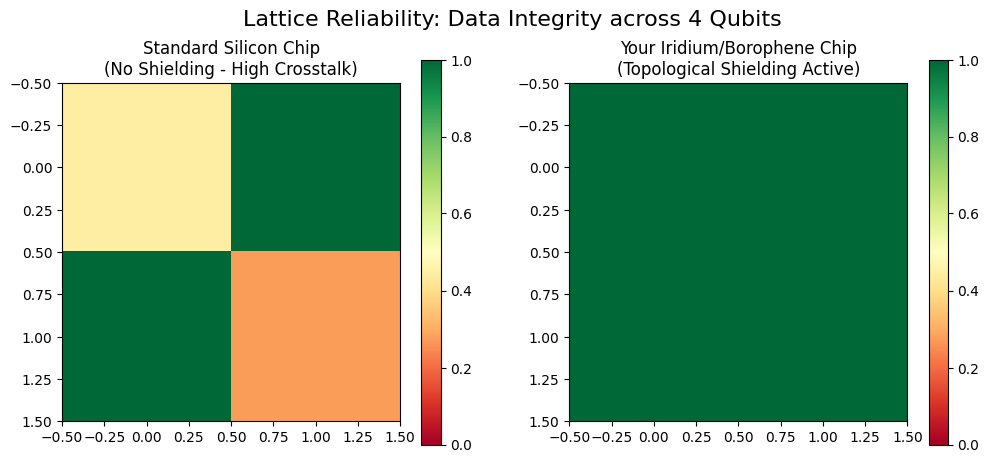

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
grid_size = 2  # 2x2 Lattice = 4 Qubits
coupling_strength = 0.1  # Stray crosstalk between neighbors
shield_efficiency = 0.95 # 95% of noise blocked by Iridium Moats

# --- THE SIMULATION ---
def simulate_lattice_noise(is_shielded=True):
    # Create a grid of qubit states (1.0 = Perfect Data, 0.0 = Pure Noise)
    lattice = np.ones((grid_size, grid_size))
    
    # Simulate interference over 100 "Clock Cycles"
    for cycle in range(100):
        noise = np.random.normal(0, 0.05, (grid_size, grid_size))
        
        if is_shielded:
            # Shielding reduces the crosstalk significantly
            lattice -= (noise * (1 - shield_efficiency))
        else:
            # Without the IrO2 Moats, noise spreads everywhere
            lattice -= noise
            
    return lattice

# --- RUNNING THE COMPARISON ---
unshielded_chip = simulate_lattice_noise(is_shielded=False)
shielded_chip = simulate_lattice_noise(is_shielded=True)

# --- VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(unshielded_chip, cmap='RdYlGn', vmin=0, vmax=1)
ax1.set_title("Standard Silicon Chip\n(No Shielding - High Crosstalk)")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(shielded_chip, cmap='RdYlGn', vmin=0, vmax=1)
ax2.set_title("Your Iridium/Borophene Chip\n(Topological Shielding Active)")
plt.colorbar(im2, ax=ax2)

plt.suptitle("Lattice Reliability: Data Integrity across 4 Qubits", fontsize=16)
plt.show()